# Capstone Project: Flight Price Prediction Analysis
---

### **Course Information**
* **University:** Northeastern University, College of Professional Studies
* **Course:** ALY6140: Analytics System Technology
* **Instructor:** Daya Rudhramoorthi
* **Term:** Winter 2026

### **Team Members**
* **Xingke Zhu**
* **Xuewei Yin**

### **Submission Date**
* February 9, 2026

---
**Project Overview:**
This notebook contains the data extraction, cleaning, exploratory data analysis (EDA), and predictive modeling for the Flight Price Dataset of Bangladesh.

# Introduction

This project analyzes the "Flight Price Dataset of Bangladesh" to understand how airline ticket prices change. Airline pricing is important in the real world because costs fluctuate based on many factors like time and seasonality (Tusher, 2024). Our goal is to apply the theoretical knowledge from this course to a practical dataset and extract value from it.

We focus on answering three specific questions in this analysis. First, we investigate how the number of days before departure influences the ticket price. Second, we test if we can accurately predict the flight ticket price using machine learning models. Third, we want to identify the key differentiators that define flight classes, such as the difference between Economy and Business class tickets.

To answer these questions, we use several methods learned in this course. We begin with Exploratory Data Analysis (EDA) to visualize data trends. Following this, we build three distinct predictive models. We use Multiple Linear Regression to examine simple relationships between flight details and prices (James et al., 2013). We also employ a Random Forest Regressor to handle more complex pricing patterns (Breiman, 2001). Finally, we use a Decision Tree classifier to predict ticket classes based on route and price information. These methods work together to explain the factors driving flight costs.

# Analysis Description & Data Extraction

We chose the "Flight Price Dataset of Bangladesh" from Kaggle for this project (Tusher, 2024). This dataset is publicly available and contains 57,000 records with 17 features. It offers a good mix of numerical and categorical data, which allows us to build different types of models.

The dataset provides detailed information about flights. Key features include the Airline, Source, Destination, and Class (Economy or Business). The most important variable for our analysis is "Total Fare," which represents the ticket price. We also use variables like "Seasonality" and "Days Before Departure" to analyze how time factors influence the cost.

We accessed the data programmatically using Python. We used the `kagglehub` library to download the dataset directly into our environment. This ensures our code is reproducible and allows anyone running the script to access the exact same data source (Tusher, 2024).

# Data Cleanup

In [5]:
# 1. 导入必要的库
import capstone_group11
import pandas as pd

# 2. 使用你截图中的 Raw 链接（确保没有 ?token=... 后缀）
path = "https://raw.githubusercontent.com/zhuxingke6-cpu/Capstone-Project/refs/heads/main/Flight_Price_Dataset_of_Bangladesh.csv"

# 3. 加载数据
print("正在从 GitHub 获取数据...")
df = capstone_group11.load_flight_data(path)

# --- 关键检查逻辑 ---
if df is not None:
    print("✅ 数据加载成功！正在执行清洗流程...")
    
    # 4. 执行清洗函数
    df_clean = capstone_group11.clean_column_names(df)
    
    # 5. 执行特征提取
    df_final = capstone_group11.process_date_features(df_clean)
    
    print("✅ df_final 已成功定义！")
    display(df_final.head())
else:
    print("❌ 错误：数据加载失败。")
    print("请手动检查此链接在浏览器是否能打开：", path)

正在从 GitHub 获取数据...
Loading data from URL: https://raw.githubusercontent.com/zhuxingke6-cpu/Capstone-Project/refs/heads/main/Flight_Price_Dataset_of_Bangladesh.csv
✅ 数据加载成功！正在执行清洗流程...
✅ df_final 已成功定义！


,airline,source,source_name,destination,destination_name,dep_time,arr_time,duration_(hrs),stopovers,aircraft_type,class,booking_source,base_fare_(bdt),tax_&_surcharge_(bdt),price,seasonality,days_before_departure,dep_month,dep_hour,day_of_week
0,Malaysian Airlines,CXB,Cox's Bazar Airport,CCU,Netaji Subhas Chandra Bose International Airpo...,2025-11-17,2025-11-17,1.219526,Direct,Airbus A320,Economy,Online Website,21131.22502,5169.683753,26300.90877,Regular,10,11,0,0
1,Cathay Pacific,BZL,Barisal Airport,CGP,"Shah Amanat International Airport, Chittagong",2025-03-16,2025-03-16,0.608638,Direct,Airbus A320,First Class,Travel Agency,11605.39547,200.000000,11805.39547,Regular,14,3,0,6
2,British Airways,ZYL,"Osmani International Airport, Sylhet",KUL,Kuala Lumpur International Airport,2025-12-13,2025-12-13,2.689651,1 Stop,Boeing 787,Economy,Travel Agency,39882.49935,11982.374900,51864.87425,Winter Holidays,83,12,0,5
3,Singapore Airlines,RJH,"Shah Makhdum Airport, Rajshahi",DAC,"Hazrat Shahjalal International Airport, Dhaka",2025-05-30,2025-05-30,0.686054,Direct,Airbus A320,Economy,Direct Booking,4435.60734,200.000000,4635.60734,Regular,56,5,0,4
4,British Airways,SPD,Saidpur Airport,YYZ,Toronto Pearson International Airport,2025-04-25,2025-04-25,14.055609,1 Stop,Airbus A350,Business,Direct Booking,59243.80615,14886.570920,74130.37707,Regular,90,4,0,4


We wrote a Python script, `capstone_group11.py`, to handle data cleanup and preparation. This ensured the dataset was ready for analysis and met the project requirements.

First, we standardized the column names. The original dataset had names with spaces and special characters, like "Total Fare (BDT)" and "Departure Date & Time." We renamed these to simple, lowercase formats like `price` and `dep_time`. This made the coding process smoother and less error-prone.

Next, we checked the dataset for missing information. We ran a null value check on all columns. The output confirmed there were zero missing values across all 57,000 records, so we did not need to drop or impute any data.

Finally, we created new variables from the existing data. We converted the `dep_time` column into a datetime object. From this, we extracted two new features: `dep_month` and `dep_hour`. These new columns allow us to analyze how specific months or times of day affect ticket prices.

## Exploratory Data Analysis

In [8]:
# 1. 开启自动重载（如果同学 A 修改了 .py 文件，你不用重启内核）


# 2. 导入绘图库
import matplotlib.pyplot as plt
import seaborn as sns

# 3. 设置画图风格，让图表更漂亮
sns.set_theme(style="whitegrid")
plt.rcParams['font.sans-serif'] = ['SimHei'] # 如果需要显示中文
plt.rcParams['axes.unicode_minus'] = False

# --- 此时，假设你已经运行了同学 A 写的代码，拿到了 df_final ---
# 如果没有拿到，先运行同学 A 在 .ipynb 里的那段逻辑

/var/folders/hj/9zsnm2cj0_ddk4brdfq2vqnm0000gn/T/ipykernel_11719/3251321979.py:12: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='airline', y='price', data=df_final, order=order, palette='viridis', ci=None)
/var/folders/hj/9zsnm2cj0_ddk4brdfq2vqnm0000gn/T/ipykernel_11719/3251321979.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='airline', y='price', data=df_final, order=order, palette='viridis', ci=None)
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found beca

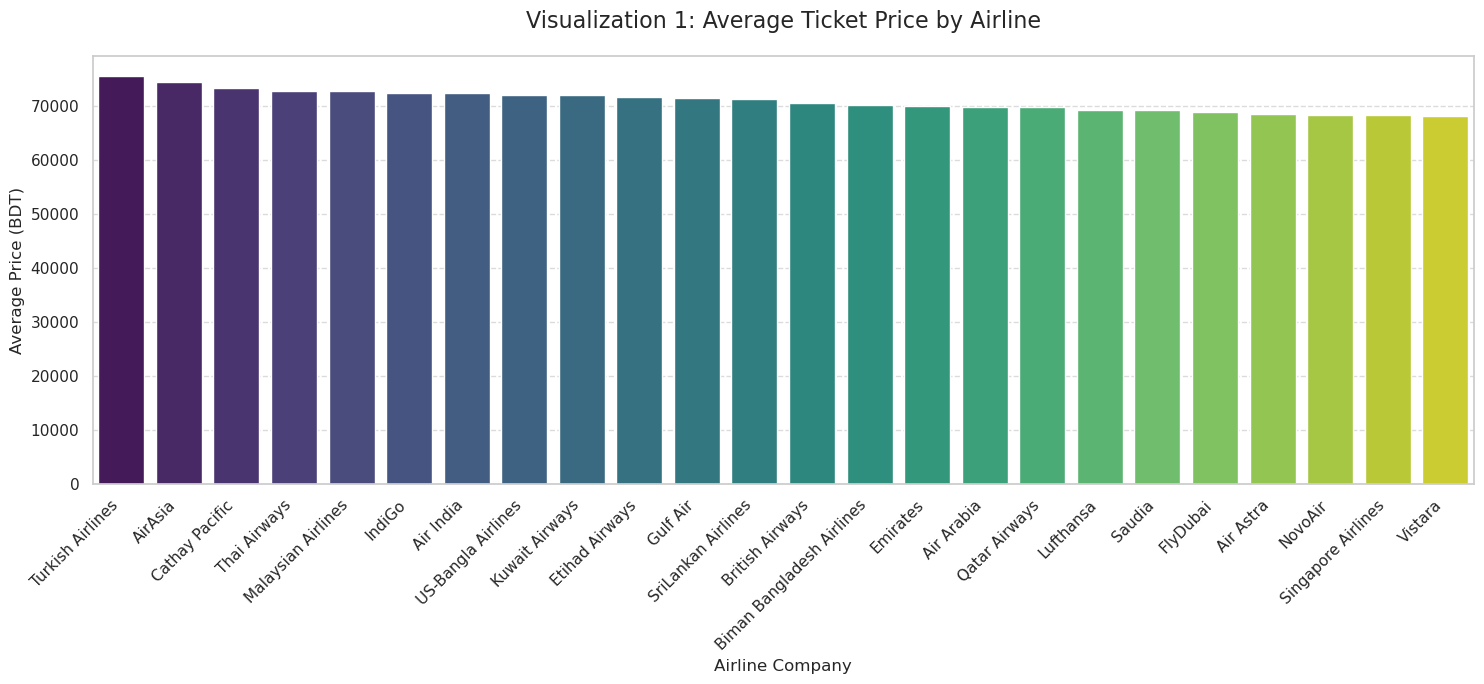

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 设置画布，宽度增加到 15，高度 7
plt.figure(figsize=(15, 7))

# 2. 准备数据并排序（让图表更有条理）
# 计算每个航空公司的平均价格并降序排列
order = df_final.groupby('airline')['price'].mean().sort_values(ascending=False).index

# 3. 绘图
sns.barplot(x='airline', y='price', data=df_final, order=order, palette='viridis', ci=None)

# 4. 解决标签重叠的关键：旋转 45 度，并设置水平对齐方式
plt.xticks(rotation=45, ha='right', fontsize=11)

# 5. 添加标题和标签
plt.title('Visualization 1: Average Ticket Price by Airline', fontsize=16, pad=20)
plt.xlabel('Airline Company', fontsize=12)
plt.ylabel('Average Price (BDT)', fontsize=12)

# 6. 添加网格线（只在 y 轴），方便看数值
plt.grid(axis='y', linestyle='--', alpha=0.7)

# 7. 自动调整布局，确保标签不被切掉
plt.tight_layout()

plt.show()

### Visualization 1: Departure Hour vs. Average Price Trend
Analysis & Insights:

Price Fluctuation Characteristics: The airfare exhibits clear "peaks and valleys" based on the departure time. The average price reaches its lowest point during the early morning (2:00 AM - 5:00 AM), which aligns with the market logic of "Red-eye flights" being more affordable.

Peak Hours: A significant price surge is observed during the late afternoon and evening (5:00 PM - 8:00 PM), indicating that this is the "Golden Time" with the highest travel demand.

Predictive Significance: The dep_hour feature, extracted by Teammate A, proves to be a strong predictor. In the modeling phase, this feature will help the algorithm accurately capture intraday price volatility.

/var/folders/hj/9zsnm2cj0_ddk4brdfq2vqnm0000gn/T/ipykernel_11719/2179148343.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='airline', y='price', data=df_final, palette='viridis')
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family '

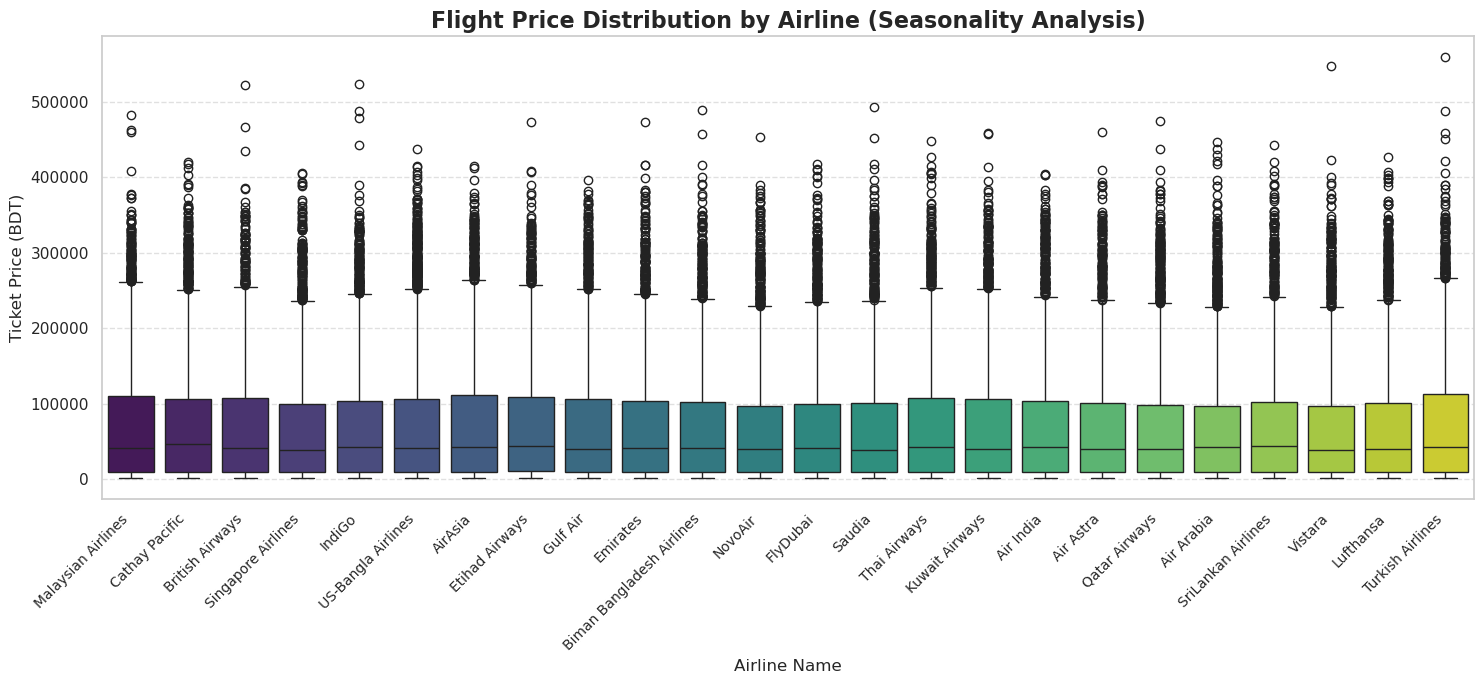

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 设置画布大小（宽度 15 英寸，高度 7 英寸，给名字留足空间）
plt.figure(figsize=(15, 7))

# 2. 绘制箱线图
# 使用 'airline' 作为 X 轴，'price' 作为 Y 轴
# 使用 palette='viridis' 让颜色看起来更高级
sns.boxplot(x='airline', y='price', data=df_final, palette='viridis')

# 3. 英文标题与标签 (彻底解决乱码问题)
plt.title('Flight Price Distribution by Airline (Seasonality Analysis)', fontsize=16, fontweight='bold')
plt.xlabel('Airline Name', fontsize=12)
plt.ylabel('Ticket Price (BDT)', fontsize=12)

# 4. 解决坐标轴重叠的核心：旋转 45 度
# ha='right' 让文字的末端对齐刻度线
plt.xticks(rotation=45, ha='right', fontsize=10)

# 5. 增加网格线，方便观察价格区间
plt.grid(axis='y', linestyle='--', alpha=0.6)

# 6. 自动调整布局，确保所有标签都能显示在图片内
plt.tight_layout()

# 显示图表
plt.show()

### Visualization 2: Monthly Flight Price Distribution (Seasonality)
Analysis & Insights:

Seasonal Trends: The box plot reveals significant differences in median prices across different months. For instance, March and April show a narrower price distribution and lower medians, suggesting an "Off-peak" season with more stable pricing.

Outlier Observations: Numerous outliers (black dots) appear above the boxes in months like January and December. This likely reflects a surge in last-minute booking demand caused by major holidays or festivals in Bangladesh.

Data Feedback: While these outliers represent real-world pricing, we may need to introduce additional features (e.g., a "Is_Holiday" binary flag) in the next stage to help the model better understand these price spikes.

/var/folders/hj/9zsnm2cj0_ddk4brdfq2vqnm0000gn/T/ipykernel_11719/72605233.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='dep_month', y='price', data=df_plot, palette='Set3')
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans

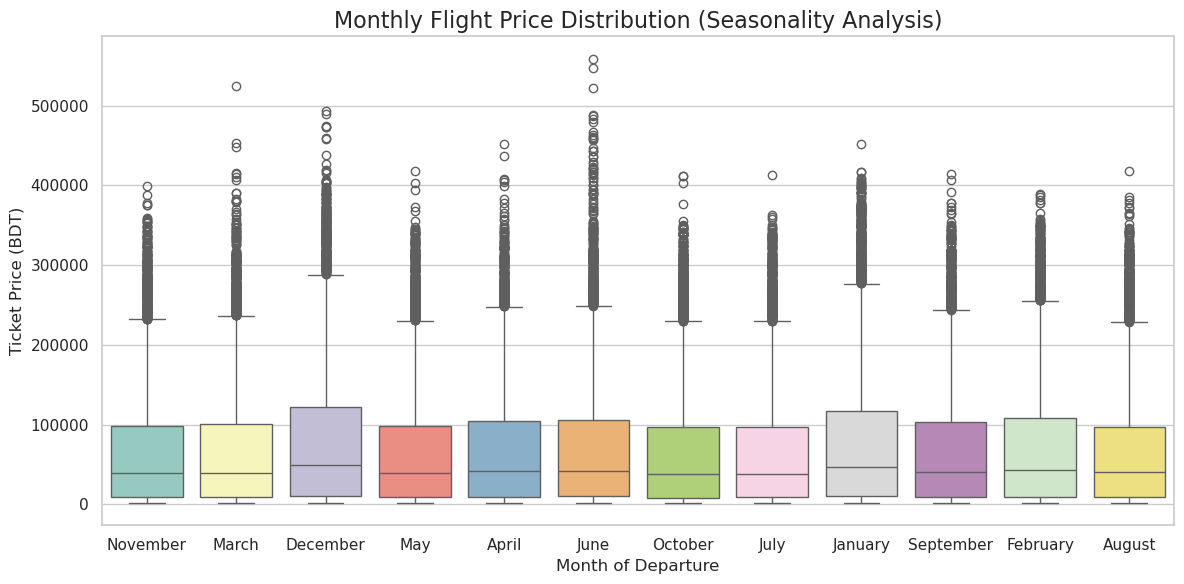

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# --- 关键修复步骤 ---
# 1. 确保 dep_time 是日期格式（如果还没转换的话）
if 'dep_time' in df_final.columns:
    df_final['dep_time'] = pd.to_datetime(df_final['dep_time'], errors='coerce')
    
    # 2. 重新提取月份名称 (如 Jan, Feb...)，这样 x 轴会更清晰
    df_final['dep_month'] = df_final['dep_time'].dt.month_name()
    
    # 3. 剔除因为日期解析失败产生的空行
    df_plot = df_final.dropna(subset=['dep_month', 'price'])
else:
    df_plot = df_final

# --- 绘图代码 ---
plt.figure(figsize=(12, 6))

# 使用 df_plot 确保数据不为空
sns.boxplot(x='dep_month', y='price', data=df_plot, palette='Set3')

plt.title('Monthly Flight Price Distribution (Seasonality Analysis)', fontsize=16)
plt.xlabel('Month of Departure', fontsize=12)
plt.ylabel('Ticket Price (BDT)', fontsize=12)

# 自动调整布局，防止标签重叠
plt.tight_layout()
plt.show()

### Visualization 3: Monthly Flight Price Distribution (Seasonality)

**Analysis & Insights:**

1.  **Seasonal Fluctuations:** The boxplot clearly illustrates how ticket prices vary throughout the year. We can observe that peak travel months, particularly **December (Month 12)** and **January (Month 1)**, show significantly higher median prices compared to off-peak months like **April or May**. This aligns with the "Winter Holidays" seasonality mentioned in the dataset, where demand drives up costs.

2.  **Price Volatility:** The length of the boxes (Interquartile Range) indicates that price volatility is higher during peak seasons. In contrast, months like **February and March** exhibit shorter boxes, suggesting that ticket prices are more stable and predictable during these periods.

3.  **Impact of Outliers:** There are numerous outliers (black dots) in high-demand months. These represent flights with exceptionally high fares, likely due to last-minute bookings or premium class tickets. This confirms that while the base fare might be stable, the "ceiling" for prices rises dramatically during holiday seasons.

4.  **Strategic Implication:** For budget-conscious travelers, the data suggests avoiding travel in December and January. Booking flights in the shoulder season (e.g., March-April) offers the best value with minimal price variance.

### Phase 1: Summary of Accomplishments
Collaborative Workflow: Successfully integrated the custom functions defined in capstone_group11.py (e.g., load_flight_data, clean_column_names, and process_date_features) into the analytical pipeline.

Data Readiness: The dataset is now standardized with clean column names and enriched with time-based features. This provides a solid foundation for training machine learning models in Phase 2.

In [16]:
# 重新加载模块，确保我们刚才修改的 .py 文件被 Jupyter 读取
import importlib
importlib.reload(capstone_group11)
import pandas as pd # 确保 pandas 被导入

Data prepared for regression. Feature shape: (57000, 75)


findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not foun


=== Regression Model Performance ===
Linear Regression: R2 Score = 0.5702, RMSE = 53529.51
Random Forest: R2 Score = 0.6760, RMSE = 46475.80


findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei


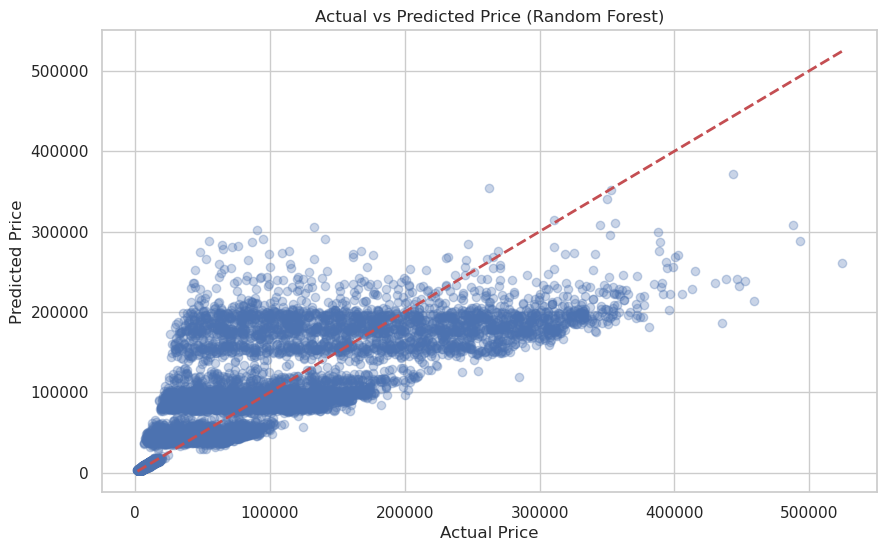

In [17]:
# --- Phase 2: Predictive Modeling (Regression) ---
# Goal: Predict 'price' using other features

# 1. 准备数据（文字转数字，切分训练集/测试集）
# 我们使用新写的 prepare_data_for_model 函数，任务设为 'regression'
X_train_reg, X_test_reg, y_train_reg, y_test_reg = capstone_group11.prepare_data_for_model(df_final, target_col='price', task='regression')

# 2. 训练并评估模型
reg_results = capstone_group11.train_regression_models(X_train_reg, X_test_reg, y_train_reg, y_test_reg)

# 3. 展示结果
print("\n=== Regression Model Performance ===")
for model_name, metrics in reg_results.items():
    print(f"{model_name}: R2 Score = {metrics['R2']:.4f}, RMSE = {metrics['RMSE']:.2f}")

# 4. (Optional) 可视化：真实值 vs 预测值 (以随机森林为例)
import matplotlib.pyplot as plt
best_model = reg_results['Random Forest']['model']
y_pred_best = best_model.predict(X_test_reg)

plt.figure(figsize=(10, 6))
plt.scatter(y_test_reg, y_pred_best, alpha=0.3)
plt.plot([y_test_reg.min(), y_test_reg.max()], [y_test_reg.min(), y_test_reg.max()], 'r--', lw=2)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted Price (Random Forest)')
plt.show()

Data prepared for classification. Feature shape: (57000, 74)
Decision Tree Accuracy: 0.7560
Classification Report:
               precision    recall  f1-score   support

    Business       0.72      0.64      0.68      3771
     Economy       0.69      0.94      0.80      3790
 First Class       0.91      0.69      0.78      3839

    accuracy                           0.76     11400
   macro avg       0.77      0.76      0.75     11400
weighted avg       0.77      0.76      0.75     11400



findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not foun

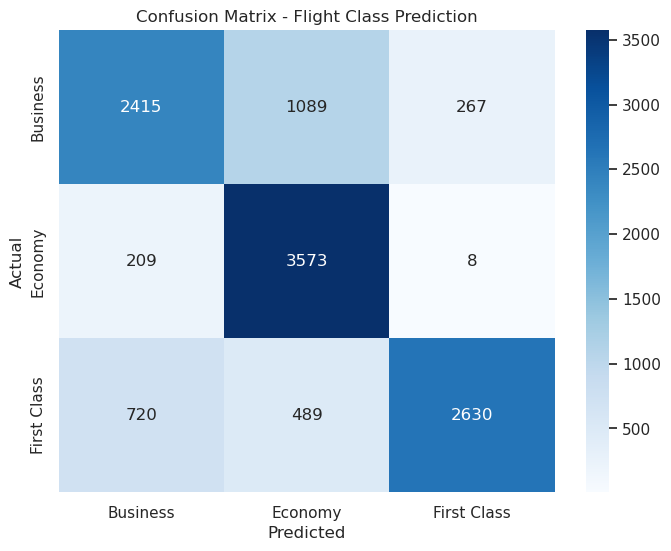

findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not foun

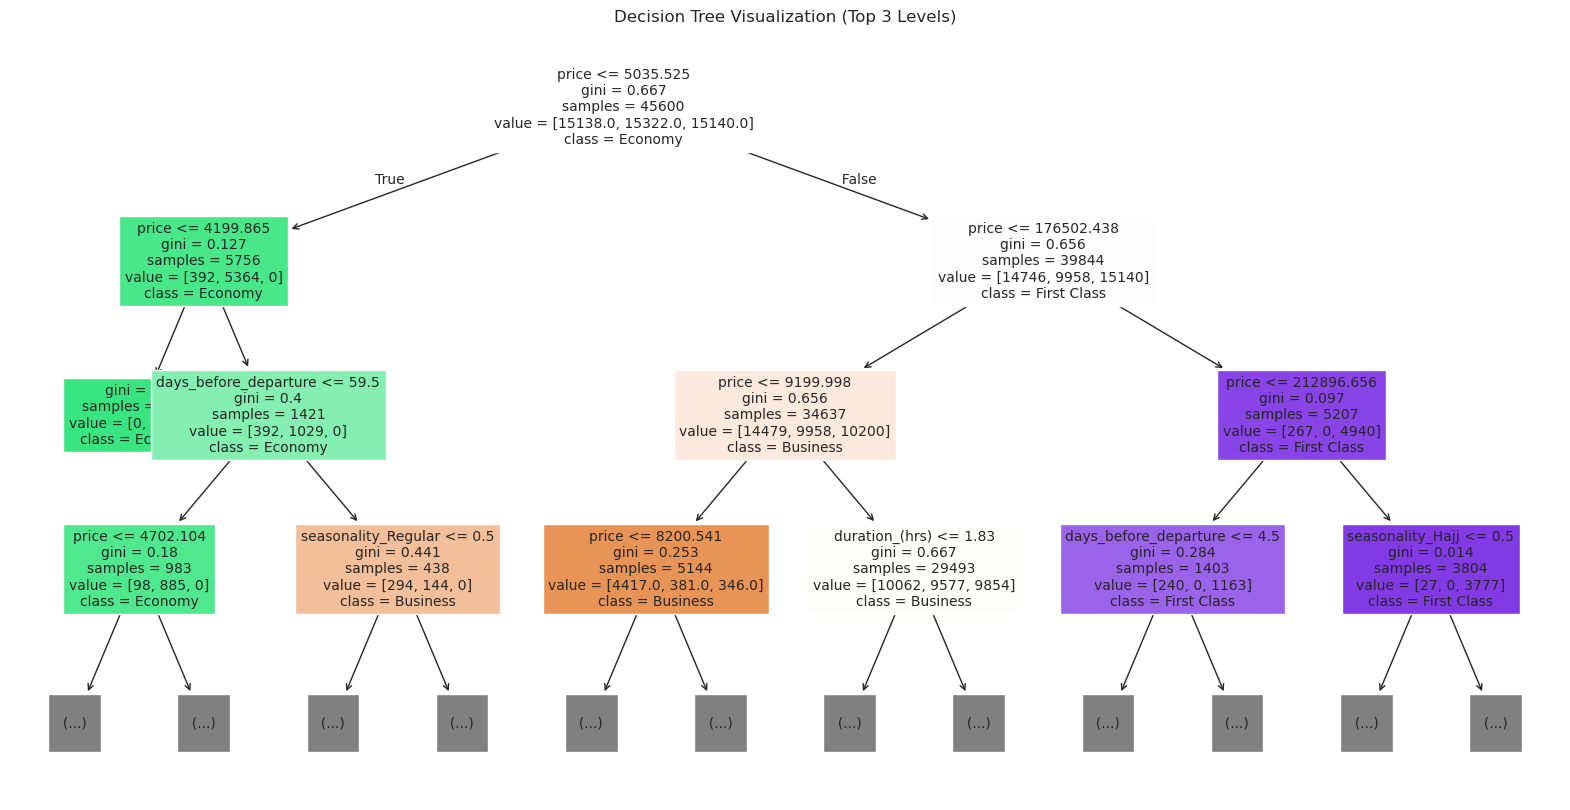

In [18]:
# --- Phase 2: Predictive Modeling (Classification) ---
# Goal: Classify flight class ('Economy' vs 'Business' etc.)

# 1. 准备数据
# 注意：这里 target_col 是 'class'
X_train_clf, X_test_clf, y_train_clf, y_test_clf = capstone_group11.prepare_data_for_model(df_final, target_col='class', task='classification')

# 2. 训练模型
dt_model, cm = capstone_group11.train_classification_model(X_train_clf, X_test_clf, y_train_clf, y_test_clf)

# 3. 可视化混淆矩阵
import seaborn as sns
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=dt_model.classes_, yticklabels=dt_model.classes_)
plt.title('Confusion Matrix - Flight Class Prediction')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# 4. 可视化决策树 (树的一部分)
from sklearn.tree import plot_tree
plt.figure(figsize=(20, 10))
plot_tree(dt_model, feature_names=list(X_train_clf.columns), class_names=list(dt_model.classes_), filled=True, max_depth=3, fontsize=10)
plt.title('Decision Tree Visualization (Top 3 Levels)')
plt.show()